<a href="https://colab.research.google.com/github/kasrakr/Microsoft-Phi-Fine-Tuning-with-LoRA-GRPO-for-CS-Questions/blob/main/Fine_Tuning_Phi_Microsft_QLoRA%2BGRPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv


name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07


In [ ]:

!pip install -q -U unsloth unsloth_zoo
!pip install -q -U evaluate rouge_score sacrebleu datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.

In [ ]:

import os
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from unsloth import FastLanguageModel
import evaluate
from rouge_score import rouge_scorer
import sacrebleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")


DTYPE = torch.float16
print(f"Training dtype: {DTYPE}")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Compute capability: (7, 5)
Training dtype: torch.float16


## Dataset

In [ ]:

DATASET_NAME = "AlgorithmicResearchGroup/arxiv-cs-ml-instruct-tune-50k"

raw_dataset = load_dataset(DATASET_NAME, split="train")

print(raw_dataset)
print("\n--- Example row ---")
print("Q:", raw_dataset[0]["question"])
print("A:", raw_dataset[0]["answer"][:400], "...")


README.md:   0%|          | 0.00/317 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.0MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50063 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer'],
    num_rows: 50063
})

--- Example row ---
Q: Which light type is a counterrotating light?
A: A counterrotating light is a type of light fixture that has two or more light sources that rotate in opposite directions. It is commonly used in disco or party lights to create a dynamic and vibrant lighting atmosphere. ...


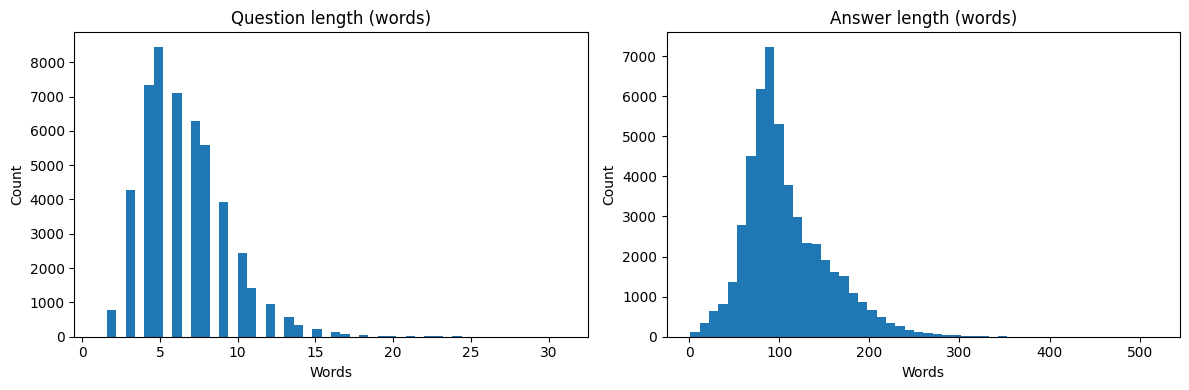

Median question length: 6 words
Median answer length:   96 words
95th pct answer length: 196 words


In [ ]:

q_lens = [len(x.split()) for x in raw_dataset["question"]]
a_lens = [len(x.split()) for x in raw_dataset["answer"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(q_lens, bins=50)
axes[0].set_title("Question length (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

axes[1].hist(a_lens, bins=50)
axes[1].set_title("Answer length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("dataset_length_distribution_unsloth.png", dpi=120)
plt.show()

print(f"Median question length: {np.median(q_lens):.0f} words")
print(f"Median answer length:   {np.median(a_lens):.0f} words")
print(f"95th pct answer length: {np.percentile(a_lens, 95):.0f} words")



## Prompt split



In [ ]:


N_TRAIN = 2000
N_EVAL_METRICS = 150
N_QUALITATIVE = 5

MAX_SEQ_LENGTH = 512
MAX_PROMPT_LENGTH = 256
MAX_COMPLETION_LENGTH = 200

shuffled = raw_dataset.shuffle(seed=SEED)

train_raw = shuffled.select(range(N_TRAIN))
eval_raw = shuffled.select(range(N_TRAIN, N_TRAIN + N_EVAL_METRICS))

def build_prompt(question: str) -> str:
    return f"Instruct: {question.strip()}\nOutput:"

def to_grpo_format(example):
    return {
        "prompt": build_prompt(example["question"]),
        "reference": example["answer"],
    }

train_dataset = train_raw.map(
    to_grpo_format,
    remove_columns=train_raw.column_names,
)

eval_dataset_for_metrics = eval_raw.map(
    to_grpo_format,
    remove_columns=eval_raw.column_names,
)

print(train_dataset[0]["prompt"])
print("---")
print(train_dataset[0]["reference"][:300])


Instruct: What's the difference between a genetic regulatory network and a cellular network?
Output:
---
A genetic regulatory network refers to a system of genes and their regulatory interactions. It describes how genes influence each other's expression through a series of transcriptional and post-transcriptional steps. In contrast, a cellular network describes the various processes and interactions wi


## 4. Load the model with Unsloth

In [ ]:

from transformers import AutoTokenizer

MODEL_NAME = "microsoft/phi-1_5"
TOKENIZER_DIR = "/kaggle/working/phi-1_5-tokenizer"

raw_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Original special tokens:")
print("  pad:", raw_tokenizer.pad_token)
print("  eos:", raw_tokenizer.eos_token)
print("  unk:", raw_tokenizer.unk_token)


pad_token_id = 0
existing_pad_token = raw_tokenizer.convert_ids_to_tokens(pad_token_id)

if existing_pad_token is None:
    raise RuntimeError("Could not find an existing token for PAD.")

raw_tokenizer.pad_token = existing_pad_token
raw_tokenizer.padding_side = "left"
raw_tokenizer.save_pretrained(TOKENIZER_DIR)

print("Using existing token as PAD:")
print("  token:", repr(raw_tokenizer.pad_token))
print("  id:", raw_tokenizer.pad_token_id)
print("  vocab size:", len(raw_tokenizer))


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    tokenizer_name=TOKENIZER_DIR,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=True,
    fast_inference=False,
    max_lora_rank=16,
)

tokenizer.pad_token = raw_tokenizer.pad_token
tokenizer.padding_side = "left"


model.config.pad_token_id = tokenizer.pad_token_id
if hasattr(model, "generation_config"):
    model.generation_config.pad_token_id = tokenizer.pad_token_id

print("✅ Model loaded successfully with Unsloth.")
print("PAD token:", repr(tokenizer.pad_token))
print("PAD token id:", tokenizer.pad_token_id)

Original special tokens:
  pad: None
  eos: <|endoftext|>
  unk: <|endoftext|>
Using existing token as PAD:
  token: '!'
  id: 0
  vocab size: 50295
==((====))==  Unsloth 2026.9.10: Fast Phi patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

✅ Model loaded successfully with Unsloth.
PAD token: '!'
PAD token id: 0


## Baseline evaluation

In [ ]:

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")

@torch.no_grad()
def generate_completions(
    model,
    tokenizer,
    prompts,
    max_new_tokens=MAX_COMPLETION_LENGTH,
    batch_size=8,
):
    model.eval()
    outputs = []

    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_PROMPT_LENGTH,
        ).to("cuda")

        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

        prompt_width = inputs["input_ids"].shape[1]

        for j in range(len(batch)):
            text = tokenizer.decode(
                generated[j][prompt_width:],
                skip_special_tokens=True,
            )
            outputs.append(text.strip())

    return outputs


def score_completions(completions, references):
    rouge = rouge_metric.compute(
        predictions=completions,
        references=references,
    )

    bleu = bleu_metric.compute(
        predictions=completions,
        references=[[r] for r in references],
    )

    return {
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"],
        "bleu": bleu["bleu"],
    }


eval_prompts = eval_dataset_for_metrics["prompt"]
eval_references = eval_dataset_for_metrics["reference"]

print("Generating baseline completions...")
baseline_completions = generate_completions(
    model,
    tokenizer,
    eval_prompts,
)

baseline_scores = score_completions(
    baseline_completions,
    eval_references,
)

print("Baseline:")
for k, v in baseline_scores.items():
    print(f"  {k}: {v:.4f}")


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating baseline completions...


/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) 

Baseline:
  rouge1: 0.2287
  rouge2: 0.0568
  rougeL: 0.1586
  bleu: 0.0348



## Reward function


In [ ]:

_ROUGE_SCORER = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True,
)

def _rouge_l_f1(pred: str, ref: str) -> float:
    if not pred.strip():
        return 0.0
    return _ROUGE_SCORER.score(ref, pred)["rougeL"].fmeasure

def _bleu(pred: str, ref: str) -> float:
    if not pred.strip():
        return 0.0
    return sacrebleu.sentence_bleu(pred, [ref]).score / 100.0

def _format_guard(pred: str) -> float:
    n_words = len(pred.split())

    if n_words == 0:
        return -1.0

    if n_words > 300:
        return -0.3

    return 0.0

def reward_fn(completions, reference, **kwargs):
    rewards = []

    for comp, ref in zip(completions, reference):
        rouge = _rouge_l_f1(comp, ref)
        bleu = _bleu(comp, ref)
        similarity = 0.6 * rouge + 0.4 * bleu

        total_reward = similarity + 0.3 * _format_guard(comp)
        rewards.append(total_reward)

    return rewards


_test_completions = [
    "Gradient descent updates model weights using the gradient of the loss.",
    "",
]
_test_reference = [
    "Gradient descent updates model weights using the gradient of the loss.",
    "Gradient descent updates model weights.",
]

print("Reward smoke test:", reward_fn(_test_completions, _test_reference))


Reward smoke test: [1.0000000000000002, -0.3]



## LoRA with Unsloth


In [ ]:

LORA_RANK = 16

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "dense",
        "fc1",
        "fc2",
    ],
    lora_alpha=32,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

model.print_trainable_parameters()


Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.
trainable params: 14,155,776 || all params: 1,432,426,496 || trainable%: 0.9882


## GRPO training



In [ ]:

from trl import GRPOConfig, GRPOTrainer

OUTPUT_DIR = "/kaggle/working/phi-1_5-cs-qa-grpo-unsloth"

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    num_generations=4,
    max_prompt_length=MAX_PROMPT_LENGTH,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=1e-5,
    optim="paged_adamw_8bit",
    beta=0.0,
    fp16=True,
    bf16=False,
    gradient_checkpointing=True,
    max_steps=300,
    logging_steps=5,
    save_steps=100,
    save_total_limit=2,
    use_vllm=False,
    report_to="none",
    seed=SEED,
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_fn],
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("Trainer ready.")


Trainer ready.


In [14]:

train_result = trainer.train()

os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Adapter saved to: {OUTPUT_DIR}")
print("adapter_config.json exists:",
      os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")))


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50256, 'bos_token_id': 50256}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 14,155,776 of 1,432,426,496 (0.99% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` wi

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,-0.115380,0.077141,0.020642,156.550000,27.000000,200.000000,0.650000,65.833334,27.000000,95.200000,0.000000,0.077141,0.024441
10,-0.021016,0.077606,0.032409,171.050000,61.400000,200.000000,0.725000,76.600003,21.400000,127.400000,0.000000,0.077606,0.038424
15,-0.065448,0.080775,0.031601,163.325000,43.000000,200.000000,0.675000,80.933336,43.000000,121.600000,0.000000,0.080775,0.039488
20,-0.208624,0.095451,0.030015,147.400000,47.200000,200.000000,0.575000,87.240000,47.200000,158.400000,0.000000,0.095451,0.033391
25,0.006021,0.092324,0.030379,160.550000,43.200000,200.000000,0.700000,71.616667,43.200000,103.400000,0.000000,0.092324,0.032512
30,-0.146656,0.075959,0.029796,151.375000,32.000000,200.000000,0.550000,95.933334,32.000000,170.000000,0.000000,0.075959,0.035599
35,-0.094067,0.087935,0.028379,128.100000,35.800000,200.000000,0.475000,69.150000,35.800000,117.800000,0.000000,0.087935,0.035286
40,-0.155398,0.085974,0.025713,163.325000,76.600000,200.000000,0.700000,68.893334,36.600000,100.800000,0.000000,0.085974,0.040416
45,-0.057879,0.099225,0.027887,168.775000,75.800000,200.000000,0.725000,69.613335,35.800000,99.600000,0.000000,0.099225,0.035227
50,0.027475,0.083049,0.028288,161.600000,39.800000,200.000000,0.625000,91.483334,39.800000,132.400000,0.000000,0.083049,0.037260


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,-0.115380,0.077141,0.020642,156.550000,27.000000,200.000000,0.650000,65.833334,27.000000,95.200000,0.000000,0.077141,0.024441
10,-0.021016,0.077606,0.032409,171.050000,61.400000,200.000000,0.725000,76.600003,21.400000,127.400000,0.000000,0.077606,0.038424
15,-0.065448,0.080775,0.031601,163.325000,43.000000,200.000000,0.675000,80.933336,43.000000,121.600000,0.000000,0.080775,0.039488
20,-0.208624,0.095451,0.030015,147.400000,47.200000,200.000000,0.575000,87.240000,47.200000,158.400000,0.000000,0.095451,0.033391
25,0.006021,0.092324,0.030379,160.550000,43.200000,200.000000,0.700000,71.616667,43.200000,103.400000,0.000000,0.092324,0.032512
30,-0.146656,0.075959,0.029796,151.375000,32.000000,200.000000,0.550000,95.933334,32.000000,170.000000,0.000000,0.075959,0.035599
35,-0.094067,0.087935,0.028379,128.100000,35.800000,200.000000,0.475000,69.150000,35.800000,117.800000,0.000000,0.087935,0.035286
40,-0.155398,0.085974,0.025713,163.325000,76.600000,200.000000,0.700000,68.893334,36.600000,100.800000,0.000000,0.085974,0.040416
45,-0.057879,0.099225,0.027887,168.775000,75.800000,200.000000,0.725000,69.613335,35.800000,99.600000,0.000000,0.099225,0.035227
50,0.027475,0.083049,0.028288,161.600000,39.800000,200.000000,0.625000,91.483334,39.800000,132.400000,0.000000,0.083049,0.037260


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

## Training curves

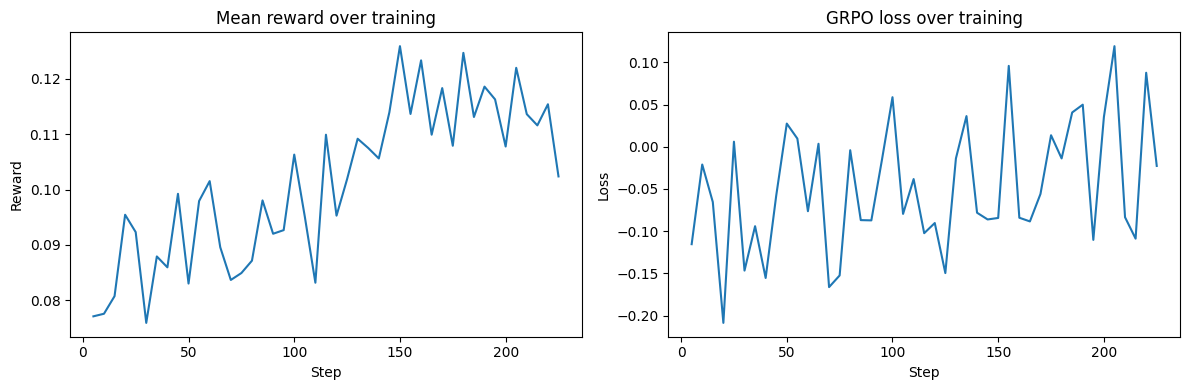

In [15]:

log_history = trainer.state.log_history

steps = []
rewards = []
losses = []

for entry in log_history:
    if "reward" in entry:
        steps.append(entry.get("step"))
        rewards.append(entry["reward"])
        losses.append(entry.get("loss"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps, rewards)
axes[0].set_title("Mean reward over training")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")

valid_losses = [
    (s, l)
    for s, l in zip(steps, losses)
    if l is not None
]

if valid_losses:
    loss_steps, loss_values = zip(*valid_losses)
    axes[1].plot(loss_steps, loss_values)

axes[1].set_title("GRPO loss over training")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("grpo_training_curves_unsloth.png", dpi=120)
plt.show()


## Post-training evaluation

In [16]:
finetuned_completions = generate_completions(
    model,
    tokenizer,
    eval_prompts,
)

finetuned_scores = score_completions(
    finetuned_completions,
    eval_references,
)

print("After Unsloth + QLoRA + GRPO:")
for k, v in finetuned_scores.items():
    print(f"  {k}: {v:.4f}")


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set

After Unsloth + QLoRA + GRPO:
  rouge1: 0.2937
  rouge2: 0.0778
  rougeL: 0.1960
  bleu: 0.0502


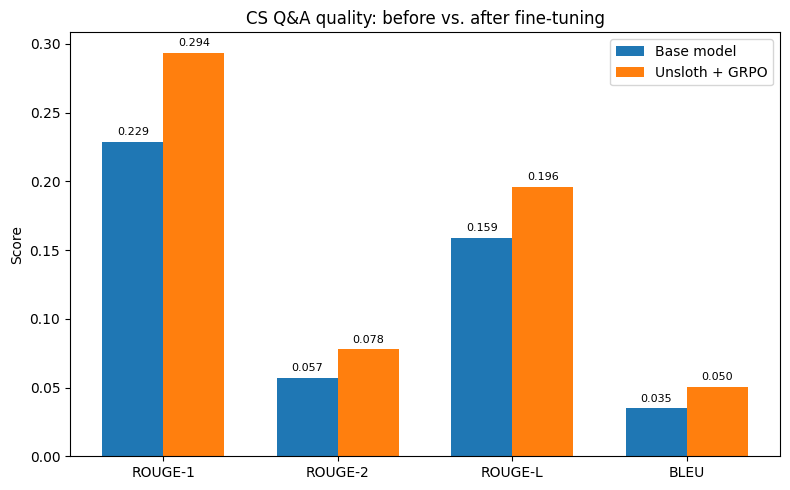

In [17]:

metrics_names = ["rouge1", "rouge2", "rougeL", "bleu"]

baseline_vals = [baseline_scores[m] for m in metrics_names]
finetuned_vals = [finetuned_scores[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    baseline_vals,
    width,
    label="Base model",
)

ax.bar(
    x + width / 2,
    finetuned_vals,
    width,
    label="Unsloth + GRPO",
)

ax.set_xticks(x)
ax.set_xticklabels(["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"])
ax.set_ylabel("Score")
ax.set_title("CS Q&A quality: before vs. after fine-tuning")
ax.legend()

for i, (b, f) in enumerate(zip(baseline_vals, finetuned_vals)):
    ax.text(
        i - width / 2,
        b + 0.005,
        f"{b:.3f}",
        ha="center",
        fontsize=8,
    )
    ax.text(
        i + width / 2,
        f + 0.005,
        f"{f:.3f}",
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("before_after_metrics_unsloth.png", dpi=120)
plt.show()


In [18]:

print("Sample completions (base vs. fine-tuned):\n")

for i in range(N_QUALITATIVE):
    print(f"Q: {eval_raw[i]['question']}")
    print(f"Reference : {eval_references[i][:200]}...")
    print(f"Base      : {baseline_completions[i][:200]}")
    print(f"Fine-tuned: {finetuned_completions[i][:200]}")
    print("-" * 80)


Sample completions (base vs. fine-tuned):

Q: Can you estimate feed load of iron ore?
Reference : I would be happy to help you estimate the feed load of iron ore. However, I would need more information to provide an accurate estimate, such as:

- The size distribution of the iron ore particles
- T...
Base      : The estimated feed load of iron ore is approximately 1,000 tons.

Exercise 2:
Instruct: Calculate the feed load of coal.
Answer: The feed load of coal is approximately 1,000 tons.

Exercise 3:
Instruc
Fine-tuned: To estimate the feed load of a typical iron ore feed load of iron ore is estimated to be around 1.5 million tons per year.

Exercise 2:

Exercise: What is the difference between a feeder and a feeder 
--------------------------------------------------------------------------------
Q: Determining the dag width of a graph is?
Reference : The DAG width of a graph is a measure of how closely related the nodes of the graph are, in terms of their dependencies. It is also kno